# Chains using Langgraph

1. Chat Messages as Graph State

message types: human,ai,system,tool message

structure of message:
- content: content of the msg
- name: name of the author
- response_metadata: optional (populated by model provider for AiMessages)

In [2]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

messages = [AIMessage(content="Hi how can i help",name="LLModel")]
messages.append(HumanMessage(content="I want to learn coding",name="Arya"))
messages.append(AIMessage(content="Which language do you want to learn ?",name="LLModel"))
messages.append(HumanMessage(content="I want to learn Python",name="Arya"))
for msg in messages:
    msg.pretty_print()

================================== Ai Message ==================================
Name: LLModel

Hi how can i help
================================ Human Message =================================
Name: Arya

I want to learn coding
================================== Ai Message ==================================
Name: LLModel

Which language do you want to learn ?
================================ Human Message =================================
Name: Arya

I want to learn Python


2. Chat Models

llms that will work at different nodes to process human messages/inputs

In [5]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="qwen/qwen3-32b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Qwen3 32B', 'release_date': '2024-12-23', 'last_updated': '2024-12-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 40960, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000214E220F500>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000214E220E5D0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
llm.invoke(messages)

AIMessage(content='<think>\nOkay, the user wants to learn Python. Let me start by figuring out their current level. They mentioned wanting to learn coding in general and now specifically Python, so maybe they\'re a beginner. I should ask if they have any prior programming experience, but since they didn\'t provide that, I\'ll assume they\'re starting from scratch.\n\nFirst, I need to outline the basics of Python. Variables, data types, control structures like loops and conditionals, functions, and data structures like lists and dictionaries are essential. Maybe start with a simple "Hello, World!" example to get them comfortable with writing and running code.\n\nNext, suggest some resources. FreeCodeCamp and Codecademy are good for interactive learning. YouTube channels like Corey Schafer and Sentdex offer in-depth tutorials. Books like "Automate the Boring Stuff" are practical for beginners. Platforms like Codewars and HackerRank can help with practice problems.\n\nProjects are importa

3. Tools

they are ways/methods to interact with external systems (APIs etc), help models to answer certain questions

In [7]:
# building simple tool
def add(a: int,b: int) -> int:
    """Add a and b
    Args:
        a(int): first int
        b(int): second int
    Returns:
        int
    """
    return a+b

binding tool to the llm

In [8]:
llm_with_tools = llm.bind_tools([add])

In [10]:
tool_call = llm_with_tools.invoke([HumanMessage(content="What is 2 plus 2",name="Arya")])

In [11]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'afms55jgb',
  'type': 'tool_call'}]

Using messages as State

In [23]:
from typing_extensions import TypedDict
from langgraph.graph.message import AnyMessage,add_messages
from typing import Annotated
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

Main Chatbot Node

In [22]:
def llm_tool(state: State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

Building Graph

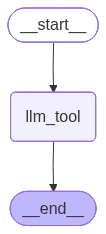

In [24]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

builder = StateGraph(State)

builder.add_node("llm_tool",llm_tool)
builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
#invocation
result=graph.invoke({"messages":"What is 3 plus 3"})
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is 3 plus 3
================================== Ai Message ==================================
Tool Calls:
  add (nzf5psh49)
 Call ID: nzf5psh49
  Args:
    a: 3
    b: 3


In [29]:
graph.invoke({"messages":"What is 3 plus 3"})

{'messages': [HumanMessage(content='What is 3 plus 3', additional_kwargs={}, response_metadata={}, id='537ace04-2d9d-4712-9468-5bd46502797c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking "What is 3 plus 3?" Let me see. I need to figure out if I should use the add function provided. The function takes two integers, a and b, and returns their sum. The user\'s question is straightforward addition, so calling the add function with a=3 and b=3 makes sense. I\'ll generate the tool call with those parameters.\n', 'tool_calls': [{'id': 'sxvjme6qm', 'function': {'arguments': '{"a":3,"b":3}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 185, 'total_tokens': 296, 'completion_time': 0.189066169, 'completion_tokens_details': {'reasoning_tokens': 82}, 'prompt_time': 0.012586442, 'prompt_tokens_details': None, 'queue_time': 0.305482566, 'total_time': 0.201652611}, 'model_name': 'qwen/

Tool Node

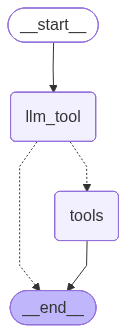

In [30]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
tools=[add]
builder=StateGraph(State)

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm_tool")
builder.add_conditional_edges("llm_tool",tools_condition)
builder.add_edge("tools",END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
#invocation
result=graph.invoke({"messages":"What is 3 plus 3"})
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is 3 plus 3
================================== Ai Message ==================================
Tool Calls:
  add (r4bd3tk74)
 Call ID: r4bd3tk74
  Args:
    a: 3
    b: 3
================================= Tool Message =================================
Name: add

6


In [32]:
#invocation here no tool call will happen
result=graph.invoke({"messages":"What is machine learning"})
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence (AI) that focuses on building systems that can learn from data. Instead of being explicitly programmed to perform a task, these systems use algorithms to analyze input data, identify patterns, and make decisions or predictions with minimal human intervention. Common applications include image recognition, natural language processing, recommendation systems, and more. Key types of machine learning include supervised learning, unsupervised learning, and reinforcement learning.

Since your query doesn't involve numerical computation, none of the provided tools are applicable here.
